In [1]:

import pandas as pd
from cdc_ml.config import BOOKING_CYCLES_PROCESSED,RECORDS_PROCESSED,PREFERENCE_PROCESSED,CUSTOMER_CLASS_INTERIM,POLLS_PROCESSED
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

2026-05-12 13:06:27.312 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [2]:
df_cycle = pd.read_parquet(BOOKING_CYCLES_PROCESSED)
df_records = pd.read_parquet(RECORDS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_poll =pd.read_parquet(POLLS_PROCESSED)

In [3]:
df_pref.head()

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,Tuesday,2025-08-19,2025-08-31,2025-08-19,0,0,0,0,0,1,1
1,0,ajithak,2,Wednesday,2025-08-19,2025-08-31,2025-08-20,0,0,0,0,0,1,1
2,0,ajithak,3,Thursday,2025-08-19,2025-08-31,2025-08-21,0,0,0,0,0,1,1
3,0,ajithak,4,Friday,2025-08-19,2025-08-31,2025-08-22,0,0,0,0,0,1,1
4,0,ajithak,5,Saturday,2025-08-19,2025-08-31,2025-08-23,0,0,0,0,0,1,1


In [4]:
df_cycle.head()

,id,username,preference,range,cycle_end_reason,cycle_start,cycle_end
0,0,ajithak,"monday to saturday after 5pm , sunday anytime",till next week,completed,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00
1,1,addity,"weeday after 7 , no tues and thurs",before oct,completed,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00
2,2,addity,"anytime on weekends , weekday after 630pm",26 oct to 14 dec,completed,2025-10-17 00:00:00+08:00,2025-10-17 20:00:00+08:00
3,3,addity,"friday and weekends anytime, other weekdays af...",Jan and feb,completed,2026-01-16 20:00:00+08:00,2026-01-19 00:00:00+08:00
4,4,bryan,"before 25 sept , weekday after 730pm , 12 pm o...",NaN,completed,2025-08-22 00:48:00+08:00,2025-09-05 16:00:00+08:00


In [5]:
df_poll.head()

,id,username,cycle_start,cycle_end,polling_hour,class_type,is_one_team,has_booking
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:15:00+08:00,3,0,0
1,1,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:15:00+08:00,3,0,0
2,2,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:15:00+08:00,3,0,0
3,3,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:15:00+08:00,3,0,0
4,4,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:15:00+08:00,3,0,0


In [6]:
df_poll.head()

,id,username,cycle_start,cycle_end,polling_hour,class_type,is_one_team,has_booking
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:15:00+08:00,3,0,0
1,1,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:15:00+08:00,3,0,0
2,2,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:15:00+08:00,3,0,0
3,3,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:15:00+08:00,3,0,0
4,4,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:15:00+08:00,3,0,0


In [7]:
df_records.head()

,id,username,lesson_at,booking_at,booking_type,class_type,is_one_team
0,0,ajithak,2025-08-28 18:50:00+08:00,2025-08-21 09:24:06.300383+08:00,0,3,0
1,1,ajithak,2025-08-28 20:40:00+08:00,2025-08-21 09:24:16.048708+08:00,0,3,0
2,2,addity,2025-09-21 14:35:00+08:00,2025-08-23 00:57:26.576198+08:00,0,3a,1
3,3,bryan,2025-08-28 20:40:00+08:00,2025-08-25 12:06:06.539664+08:00,0,3a,0
4,4,bryan,2025-08-31 12:45:00+08:00,2025-08-26 12:50:24.317931+08:00,0,3a,0


In [8]:
df_pref

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,Tuesday,2025-08-19,2025-08-31,2025-08-19,0,0,0,0,0,1,1
1,0,ajithak,2,Wednesday,2025-08-19,2025-08-31,2025-08-20,0,0,0,0,0,1,1
2,0,ajithak,3,Thursday,2025-08-19,2025-08-31,2025-08-21,0,0,0,0,0,1,1
3,0,ajithak,4,Friday,2025-08-19,2025-08-31,2025-08-22,0,0,0,0,0,1,1
4,0,ajithak,5,Saturday,2025-08-19,2025-08-31,2025-08-23,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3980,121,addity,2,Wednesday,2025-10-16,2025-12-14,2025-12-10,0,0,0,0,0,1,1
3981,121,addity,3,Thursday,2025-10-16,2025-12-14,2025-12-11,0,0,0,0,0,1,1
3982,121,addity,4,Friday,2025-10-16,2025-12-14,2025-12-12,0,0,0,0,0,1,1
3983,121,addity,5,Saturday,2025-10-16,2025-12-14,2025-12-13,1,1,1,1,1,1,1


In [9]:
df_records = df_records.assign(day_of_week=df_records["booking_at"].dt.day_of_week).assign(hour=df_records["booking_at"].dt.hour)

In [10]:
week = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [11]:
df_records.info()

<class 'pandas.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype                         
---  ------        --------------  -----                         
 0   id            524 non-null    int64                         
 1   username      524 non-null    str                           
 2   lesson_at     310 non-null    datetime64[ns, Asia/Singapore]
 3   booking_at    524 non-null    datetime64[ns, Asia/Singapore]
 4   booking_type  524 non-null    int64                         
 5   class_type    524 non-null    str                           
 6   is_one_team   524 non-null    int64                         
 7   day_of_week   524 non-null    int32                         
 8   hour          524 non-null    int32                         
dtypes: datetime64[ns, Asia/Singapore](2), int32(2), int64(3), str(2)
memory usage: 36.0 KB


   booking_type  count
0             1    224
1             0    219
2             2     81


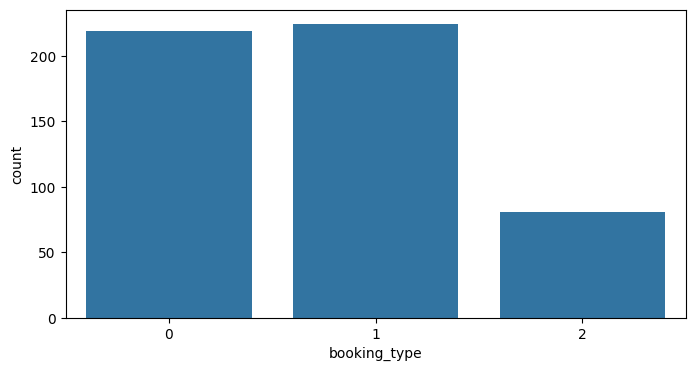

In [12]:
def get_booking_type_count(df:pd.DataFrame):
    type_counts = df["booking_type"].value_counts().reset_index()
    print(type_counts)
    fig,ax= plt.subplots(figsize=(8,4))
    sns.barplot(data=type_counts,x="booking_type",y="count")



get_booking_type_count(df_records)

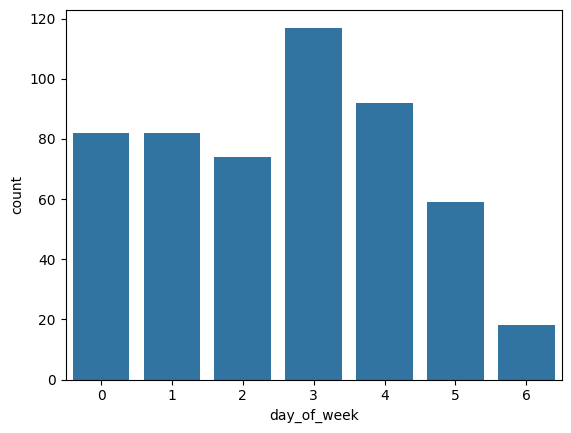

In [13]:
def get_booking_occurance_count(df:pd.DataFrame):
    count = df.groupby(["day_of_week"])["username"].count().reset_index(name="count")
    sns.barplot(data=count,x="day_of_week",y="count")

get_booking_occurance_count(df_records)

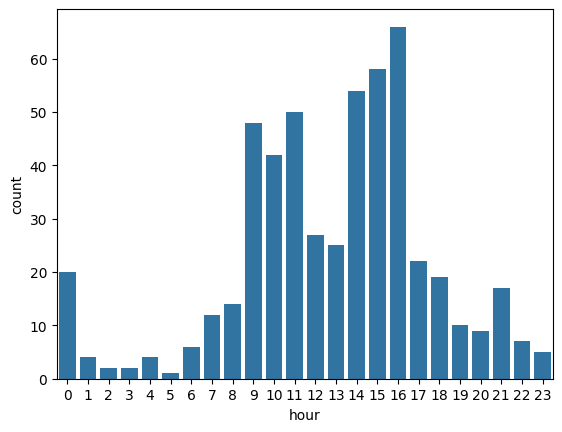

In [14]:
def get_booking_occurance_time_count(df:pd.DataFrame):
    count = df.groupby(["hour"])["username"].count().reset_index(name="count")

    sns.barplot(data=count,x="hour",y="count")

get_booking_occurance_time_count(df_records)

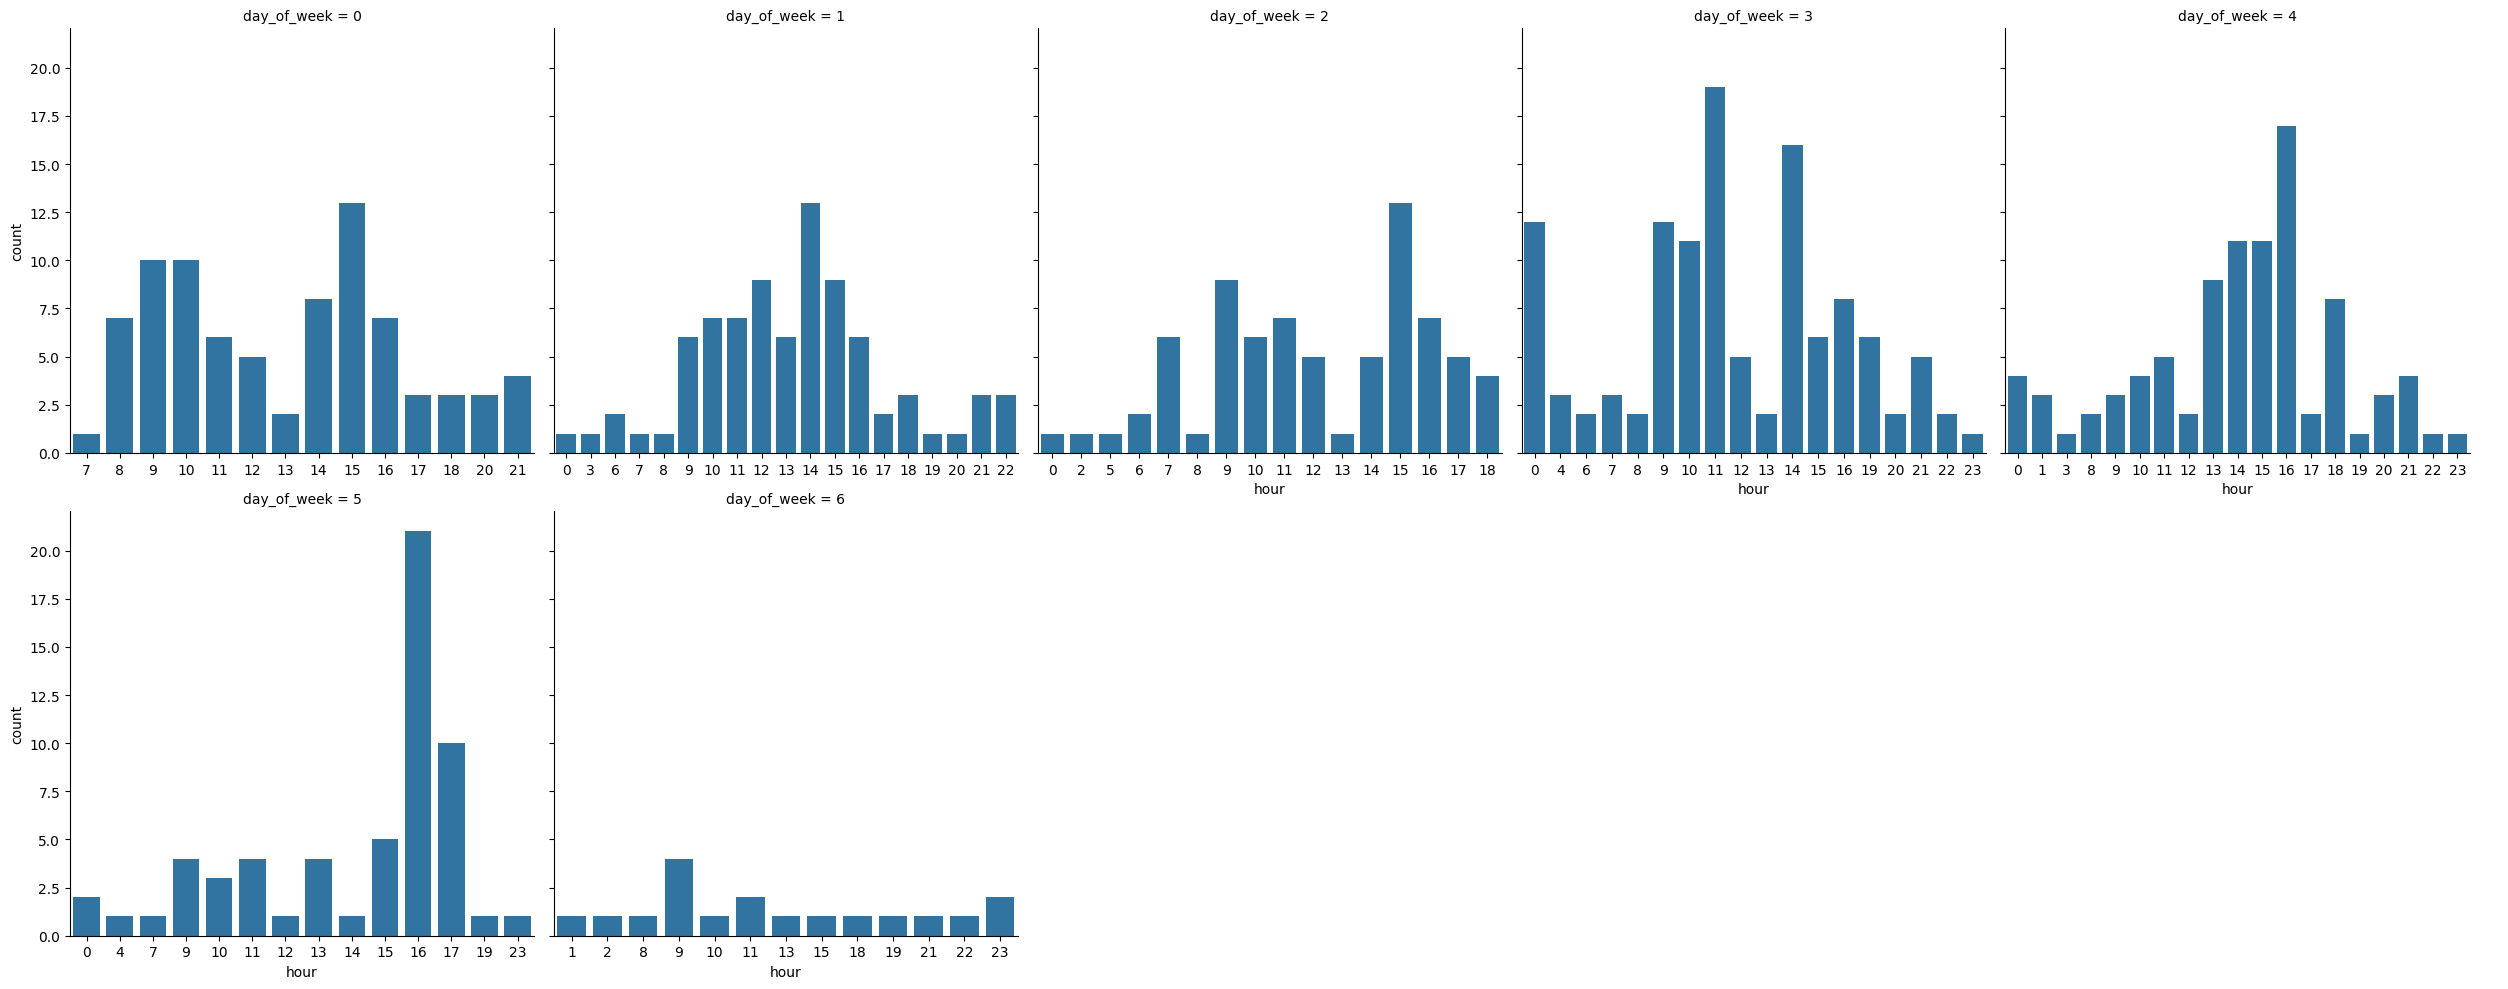

In [15]:
def get_booking_occurance_day_by_day(df:pd.DataFrame):
    count = df.groupby(["day_of_week","hour"])["username"].count().reset_index(name="count")
    sns.catplot(data=count,x="hour",y="count",col="day_of_week",kind="bar",col_wrap=5,sharex=False)

get_booking_occurance_day_by_day(df_records)

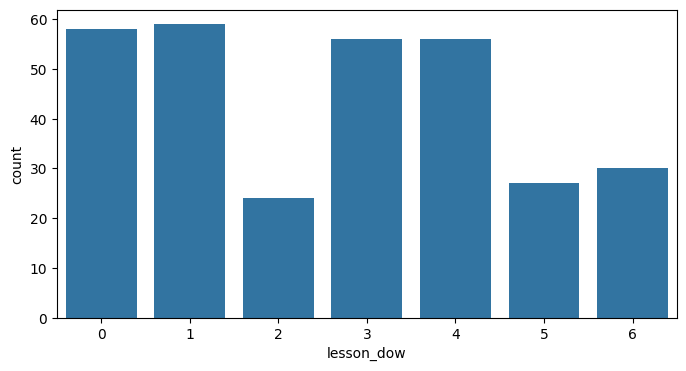

In [16]:
def get_booked_lesson_count_dow(df:pd.DataFrame):
    df = df.loc[~(df["lesson_at"].isna())].assign(lesson_hour=lambda x:x["lesson_at"].dt.hour,
                                                lesson_dow=lambda x:x["lesson_at"].dt.day_of_week
                                                  )
    count = df.groupby(["lesson_dow"])["username"].count().reset_index(name="count")
    fig,ax = plt.subplots(figsize=(8,4))
    sns.barplot(data=count,x="lesson_dow",y="count")


get_booked_lesson_count_dow(df_records)

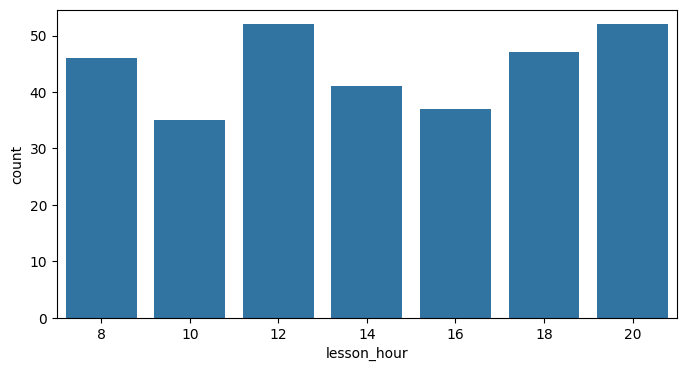

In [17]:

def get_booked_lesson_count_time(df:pd.DataFrame):
    df = df.loc[~(df["lesson_at"].isna())].assign(lesson_hour=lambda x:x["lesson_at"].dt.hour,
                                                lesson_dow=lambda x:x["lesson_at"].dt.day_of_week
                                                  )
    count = df.groupby(["lesson_hour"])["username"].count().reset_index(name="count")
    fig,ax = plt.subplots(figsize=(8,4))
    sns.barplot(data=count,x="lesson_hour",y="count")


get_booked_lesson_count_time(df_records)

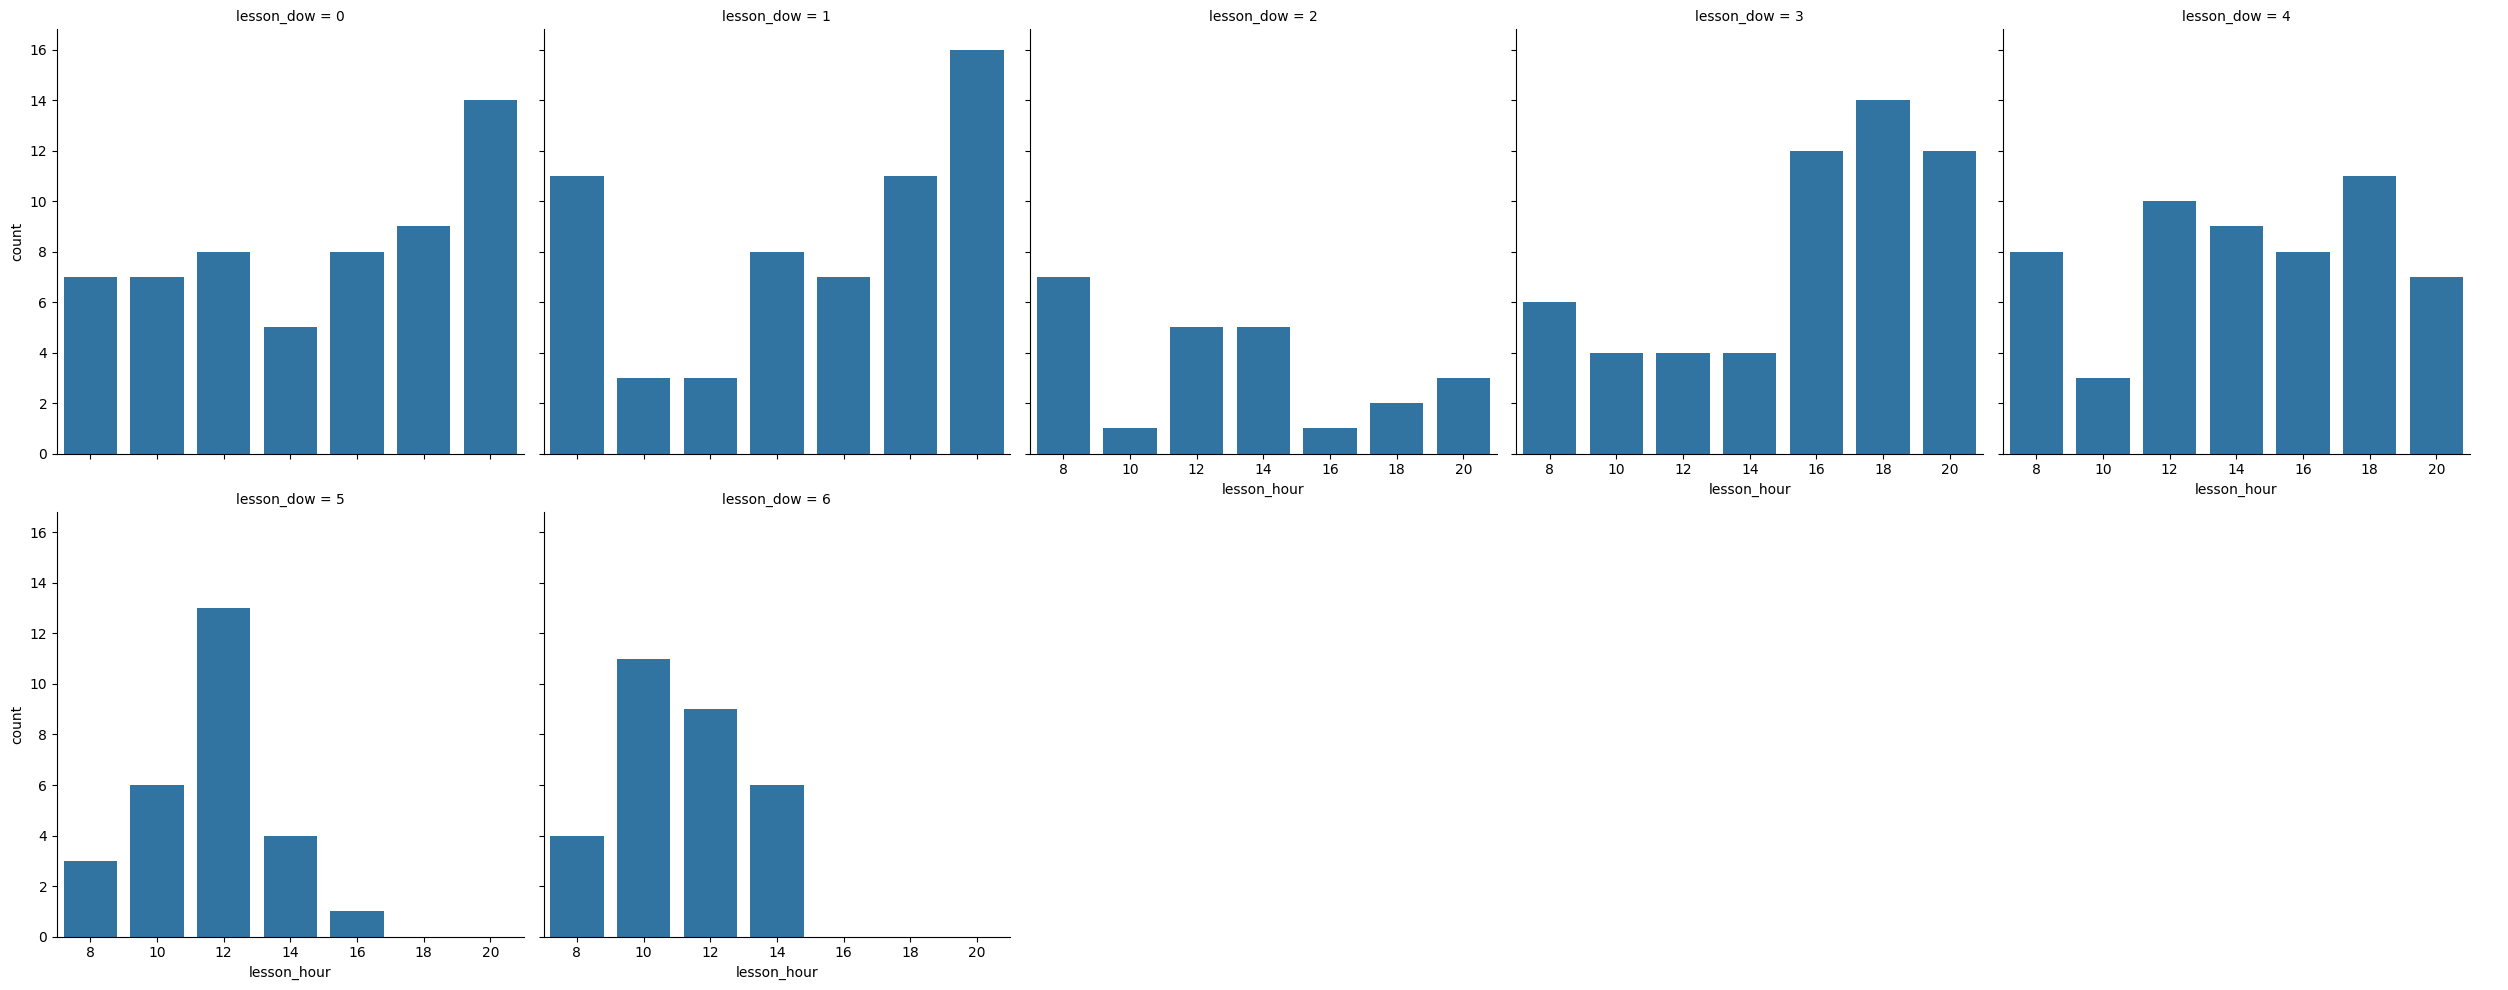

In [18]:

def get_booked_lesson_count(df:pd.DataFrame):
    df = df.loc[~(df["lesson_at"].isna())].assign(lesson_hour=lambda x:x["lesson_at"].dt.hour,
                                                lesson_dow=lambda x:x["lesson_at"].dt.day_of_week
                                                  )
    count = df.groupby(["lesson_dow","lesson_hour"])["username"].count().reset_index(name="count")
    sns.catplot(data=count,x="lesson_hour",y="count",col="lesson_dow",col_wrap=5,kind="bar")


get_booked_lesson_count(df_records)

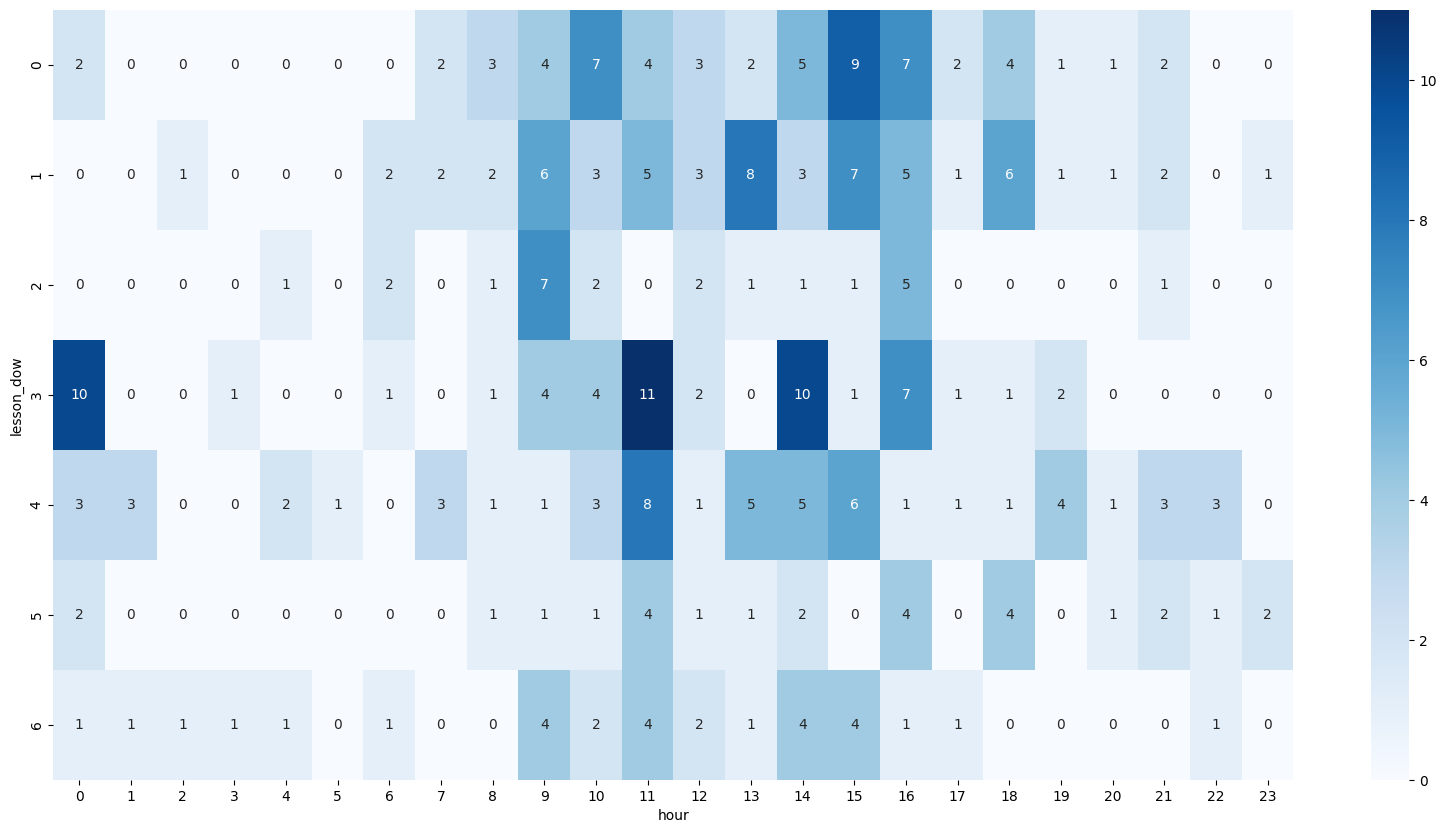

In [19]:
def booking_lesson_heatmap(df:pd.DataFrame):

    df = df.loc[~(df["lesson_at"].isna())].assign(lesson_hour=lambda x:x["lesson_at"].dt.hour,lesson_dow=lambda x:x["lesson_at"].dt.day_of_week)
    df= df.groupby(["hour","lesson_dow"])["username"].count().reset_index(name="count")
    
    df_pv = pd.pivot_table(data=df,index="lesson_dow",columns="hour",values="count",fill_value=0,aggfunc="sum")
    fig,ax = plt.subplots(figsize=(20,10))
    sns.heatmap(df_pv,annot=True,fmt="d",cmap="Blues",vmin=0)

booking_lesson_heatmap(df_records)


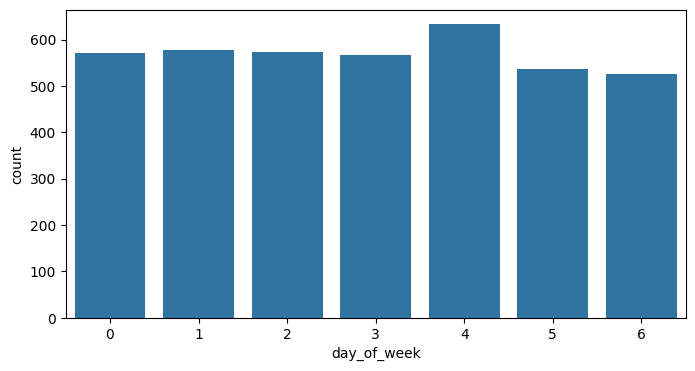

In [20]:
def get_preference_dow(df:pd.DataFrame):
    count = df.groupby(["day_of_week"])["username"].count().reset_index(name="count")
    fig,ax = plt.subplots(figsize=(8,4))
    sns.barplot(data=count,x="day_of_week",y="count")

get_preference_dow(df_pref)

In [21]:

melts = ["t_0830",  "t_1020",  "t_1245",  "t_1435",  "t_1625",  "t_1850",  "t_2040" ]
df_pref = df_pref.melt(
        id_vars=["username","day_of_week","pref_start","pref_end"],
        value_vars=melts,
        var_name="slots",
        value_name="available",
        ignore_index=True
    ).query("available==1")

      username  day_of_week pref_start   pref_end   slots  available
5      ajithak            6 2025-08-19 2025-08-31  t_0830          1
12     ajithak            6 2025-08-19 2025-08-31  t_0830          1
15      addity            6 2025-08-13 2025-09-30  t_0830          1
19      addity            6 2025-08-13 2025-09-30  t_0830          1
23      addity            6 2025-08-13 2025-09-30  t_0830          1
...        ...          ...        ...        ...     ...        ...
27890   addity            2 2025-10-16 2025-12-14  t_2040          1
27891   addity            3 2025-10-16 2025-12-14  t_2040          1
27892   addity            4 2025-10-16 2025-12-14  t_2040          1
27893   addity            5 2025-10-16 2025-12-14  t_2040          1
27894   addity            6 2025-10-16 2025-12-14  t_2040          1

[20843 rows x 6 columns]


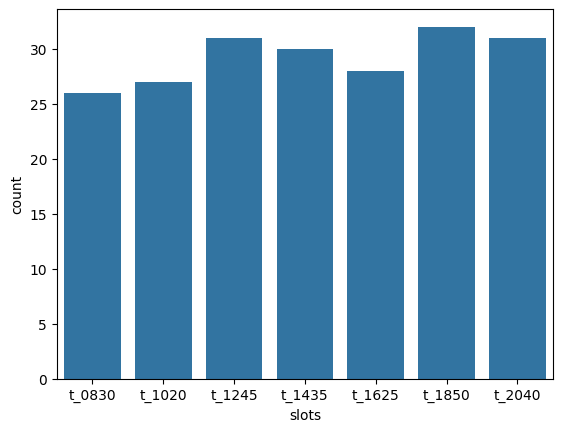

In [22]:
def get_preference_hour(df:pd.DataFrame):
    print(df)
    count = df.groupby("slots")["username"].nunique().reset_index(name="count")
    sns.barplot(data=count,x="slots",y="count")
    
get_preference_hour(df_pref)

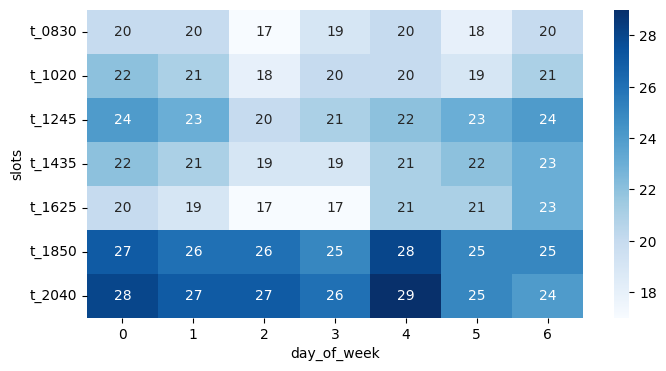

In [23]:
def preference_heatmap(df:pd.DataFrame):
    count = df.groupby(["day_of_week","slots"])["username"].nunique().reset_index(name="count")
    pv = pd.pivot(data=count,index="slots",columns="day_of_week",values="count")
    fig,ax = plt.subplots(figsize=(8,4))
    sns.heatmap(pv,annot=True,fmt="d",cmap="Blues")

preference_heatmap(df_pref)